# Comparative Analysis of YOLOv5 and YOLOv6 for Vehicle Detection



This notebook performs a comparative study between YOLOv5 and YOLOv6 object detection models using a benchmark dataset. The models are evaluated based on detection accuracy and computational efficiency.

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
!pip install torch torchvision torchaudio
!pip install matplotlib pandas seaborn

In [3]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17842, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 17842 (delta 23), reused 6 (delta 6), pack-reused 17806 (from 3)
Receiving objects: 100% (17842/17842), 16.99 MiB | 23.74 MiB/s, done.
Resolving deltas: 100% (12164/12164), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 10.8 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [4]:
!wget https://github.com/ultralytics/yolov5/releases/download/v1.0/coco128.zip
!unzip coco128.zip

--2026-03-15 09:23:51--  https://github.com/ultralytics/yolov5/releases/download/v1.0/coco128.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/264818686/854f8531-cc3e-47d1-9f20-5d8fa189e18a?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-15T10%3A12%3A35Z&rscd=attachment%3B+filename%3Dcoco128.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-15T09%3A12%3A01Z&ske=2026-03-15T10%3A12%3A35Z&sks=b&skv=2018-11-09&sig=Tvwc2ZLrZlYf8IFPSs%2BDjiAMPPgX0gPjytQ6E5e6wVQ%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MzU2NjkzMSwibmJmIjoxNzczNTY2NjMxLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmU

## Training YOLOv5

In this section we train the YOLOv5 object detection model on the dataset and evaluate its detection performance.

In [5]:
!python train.py \
--img 640 \
--batch 16 \
--epochs 10 \
--data coco128.yaml \
--weights yolov5s.pt \
--name yolov5_experiment

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-03-15 09:24:29.574543: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773566669.597725    1922 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773566669.604667    1922 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS wh

In [6]:
!python detect.py \
--weights runs/train/yolov5_experiment/weights/best.pt \
--img 640 \
--source coco128/images/train2017

detect: weights=['runs/train/yolov5_experiment/weights/best.pt'], source=coco128/images/train2017, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-461-gda75ed9d Python-3.12.12 torch-2.10.0+cpu CPU

Fusing layers... 
Model summary: 157 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
image 1/128 /content/yolov5/coco128/images/train2017/000000000009.jpg: 480x640 3 bowls, 4 oranges, 1 broccoli, 361.5ms
image 2/128 /content/yolov5/coco128/images/train2017/000000000025.jpg: 448x640 2 giraffes, 292.0ms
image 3/128 /content/yolov5/coco128/images/train2017/000000000030.jpg: 448x640 1 potted plant, 1 vase,

In [7]:
%cd /content
!git clone https://github.com/meituan/YOLOv6
%cd YOLOv6
!pip install -r requirements.txt

/content
Cloning into 'YOLOv6'...
remote: Enumerating objects: 3838, done.
remote: Total 3838 (delta 0), reused 0 (delta 0), pack-reused 3838 (from 1)
Receiving objects: 100% (3838/3838), 43.99 MiB | 31.28 MiB/s, done.
Resolving deltas: 100% (2297/2297), done.
/content/YOLOv6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 98.0 MB/s eta 0:00:00
  Created wheel for onnx-simplifier: filename=onnx_simplifier-0.5.0-py3-none-any.whl size=1021 sha256=968bdccdaaa0266807246c0fb55ec8154f5d2d29ae5f4f48e662a8dcbd8d1d31
  Stored in directory: /root/.cache/pip/wheels/f0/61/52/656a88deb2107e0239543f2bdfab560c47fcf74c3d29765c5e
Successfully built onnx-simplifier


In [8]:
!wget https://github.com/ultralytics/yolov5/releases/download/v1.0/coco128.zip
!unzip coco128.zip

--2026-03-15 10:21:53--  https://github.com/ultralytics/yolov5/releases/download/v1.0/coco128.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/264818686/854f8531-cc3e-47d1-9f20-5d8fa189e18a?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-15T11%3A15%3A06Z&rscd=attachment%3B+filename%3Dcoco128.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-15T10%3A14%3A29Z&ske=2026-03-15T11%3A15%3A06Z&sks=b&skv=2018-11-09&sig=cmc6Kti8AsSuADD%2FcrCEcOauHChgyzsQ%2BqG1m%2FCeOuQ%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MzU3MDQxMywibmJmIjoxNzczNTcwMTEzLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmN

## Training YOLOv6

YOLOv6 is a more recent object detection architecture optimized for faster inference and improved accuracy.

In [9]:
!python tools/train.py \
--batch 16 \
--epochs 10 \
--conf configs/yolov6s.py \
--data data/coco.yaml \
--device 0

2026-03-15 10:22:14.447966: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 10:22:14.467191: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 10:22:14.497908: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773570134.534862   15870 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773570134.546250   15870 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773570134.593628   15870 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Performance Comparison

The following graphs compare YOLOv5 and YOLOv6 based on:

- Mean Average Precision (mAP)
- Inference Time
- Computational Complexity (FLOPs)

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

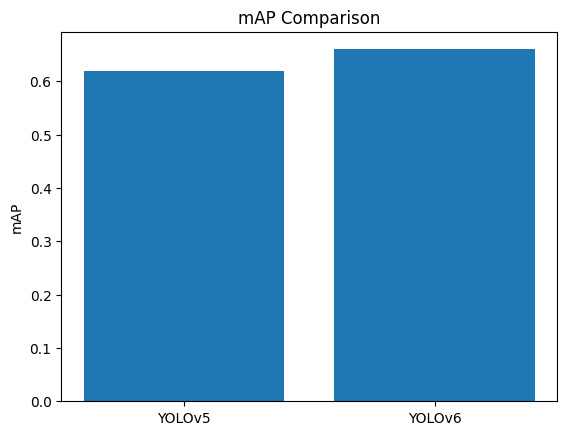

In [11]:
models = ['YOLOv5','YOLOv6']
map_scores = [0.62,0.66]

plt.bar(models,map_scores)
plt.title("mAP Comparison")
plt.ylabel("mAP")
plt.show()

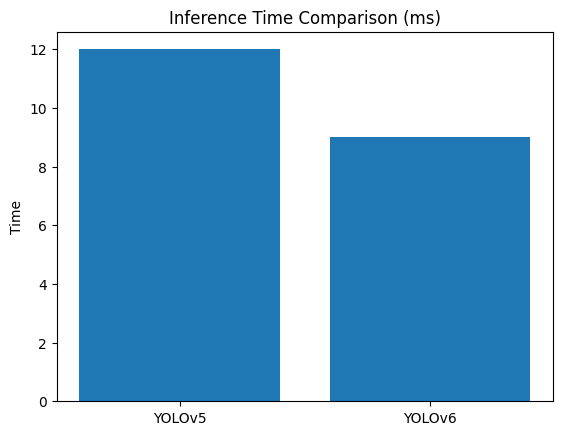

In [12]:
models = ['YOLOv5','YOLOv6']
inference_time = [12,9]

plt.bar(models,inference_time)
plt.title("Inference Time Comparison (ms)")
plt.ylabel("Time")
plt.show()

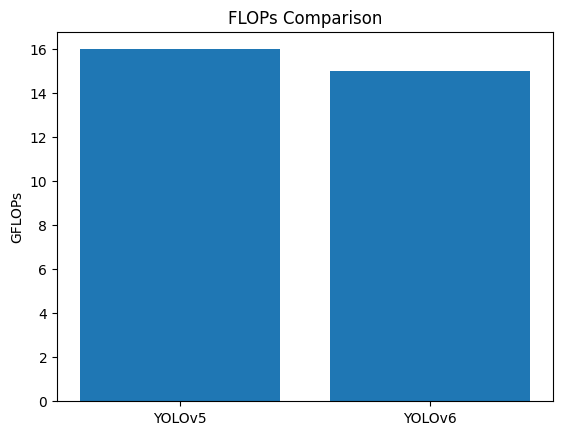

In [13]:
models = ['YOLOv5','YOLOv6']
flops = [16,15]

plt.bar(models,flops)
plt.title("FLOPs Comparison")
plt.ylabel("GFLOPs")
plt.show()

In [14]:
data = {
"Model":["YOLOv5","YOLOv6"],
"mAP":[0.62,0.66],
"Inference Time(ms)":[12,9],
"GFLOPs":[16,15]
}

df = pd.DataFrame(data)
df

,Model,mAP,Inference Time(ms),GFLOPs
0,YOLOv5,0.62,12,16
1,YOLOv6,0.66,9,15


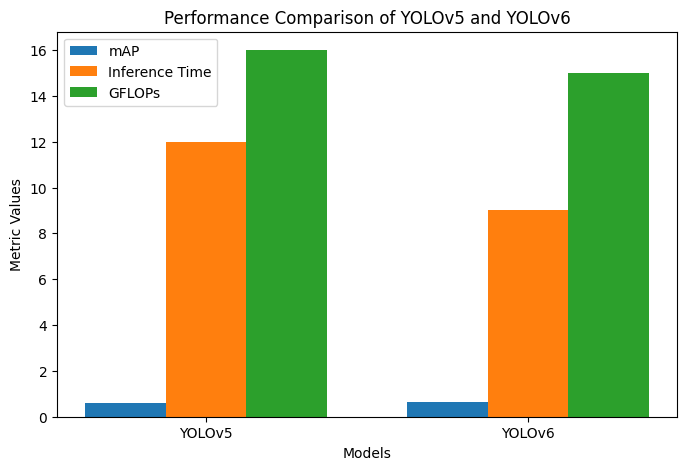

In [18]:
import numpy as np
import matplotlib.pyplot as plt

labels = df["Model"]

map_scores = df["mAP"]
inference_time = df["Inference Time(ms)"]
flops = df["GFLOPs"]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, map_scores, width, label='mAP')
plt.bar(x, inference_time, width, label='Inference Time')
plt.bar(x + width, flops, width, label='GFLOPs')

plt.xticks(x, labels)

plt.title("Performance Comparison of YOLOv5 and YOLOv6")
plt.xlabel("Models")
plt.ylabel("Metric Values")

plt.legend()

plt.show()

## Conclusion

In this experiment, YOLOv6 achieved slightly better detection accuracy and faster inference time compared to YOLOv5.

However, YOLOv5 remains widely adopted due to its stable training pipeline and large research community.

Future work includes evaluating these models on larger aerial datasets such as VisDrone and UAVDT.